In [27]:
import torch
# print(torch.cuda.is_available())
# print(torch.cuda.get_device_name())
import numpy as np
import glob
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

cam_pt_dir = r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data\dataset\*.pt"
pt_files = sorted(glob.glob(cam_pt_dir))

degree_only = []
posture_only = []
all_feat = []
speed_only = []
accel_only = []

deg_acc_combined = []

for f in pt_files:
    data = torch.load(f, weights_only=False)
    # upper_body = feats[:, :11, :]
    upper = data['landmarks'][:, :15, :] #above knees
    pos_feats = upper.reshape(upper.shape[0], -1).numpy()
    posture_only.append(pos_feats)

    deg_feats = data['features'].reshape(data['features'].shape[0], -1).numpy()
    degree_only.append(deg_feats)


    speed_feats = data['speed'].reshape(data['speed'].shape[0], -1).numpy()
    speed_only.append(speed_feats)  

    accel_feats = data['acceleration'].reshape(data['acceleration'].shape[0], -1).numpy()
    accel_only.append(accel_feats)
    
    combined_feat = np.hstack([pos_feats, deg_feats])

    deg_speed_accel_feat = np.hstack([deg_feats, speed_feats])
    
    all_feat.append(combined_feat)
    deg_acc_combined.append(deg_speed_accel_feat)
    
    
    
X_all = np.vstack(all_feat)
X_pos = np.vstack(posture_only)
X_deg = np.vstack(degree_only)
X_speed = np.vstack(speed_only)
X_accel = np.vstack(accel_only)
X_deg_speed_accel = np.vstack(deg_acc_combined)

scaler = StandardScaler()

X_scaled_all = scaler.fit_transform(X_all)
X_scaled_pos = scaler.fit_transform(X_pos)
X_scaled_deg = scaler.fit_transform(X_deg)
X_scaled_speed = scaler.fit_transform(X_speed)
X_scaled_accel = scaler.fit_transform(X_accel)
X_scaled_deg_speed_accel = scaler.fit_transform(X_deg_speed_accel)




print("Feature shape:", X_scaled_all.shape)
print("Posture feature shape:", X_scaled_pos.shape)
print("Degree feature shape:", X_scaled_deg.shape)
print("Speed feature shape:", X_scaled_speed.shape)
print("Acceleration feature shape:", X_scaled_accel.shape)
print("Combined feature shape:", X_scaled_deg_speed_accel.shape)


Feature shape: (61104, 39)
Posture feature shape: (61104, 30)
Degree feature shape: (61104, 9)
Speed feature shape: (61104, 17)
Acceleration feature shape: (61104, 17)
Combined feature shape: (61104, 26)


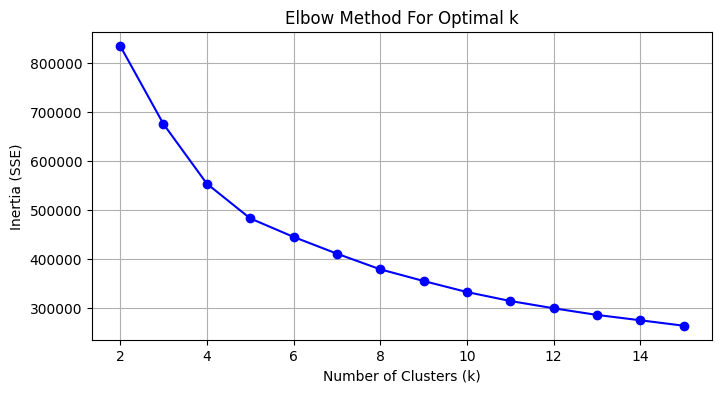

In [28]:
inertias = []
K_range = range(2, 16) #

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_deg_speed_accel)
    inertias.append(kmeans.inertia_)

#
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (SSE)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

In [35]:

optimal_k = 8
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)

labels = kmeans.fit_predict(X_scaled_deg_speed_accel)

counts = np.bincount(labels)
for i, c in enumerate(counts):
    print(f"cluster {i}: {c} {c/len(labels)*100:.1f}%")

cluster 0: 1648 2.7%
cluster 1: 33543 54.9%
cluster 2: 54 0.1%
cluster 3: 14203 23.2%
cluster 4: 10536 17.2%
cluster 5: 311 0.5%
cluster 6: 769 1.3%
cluster 7: 40 0.1%


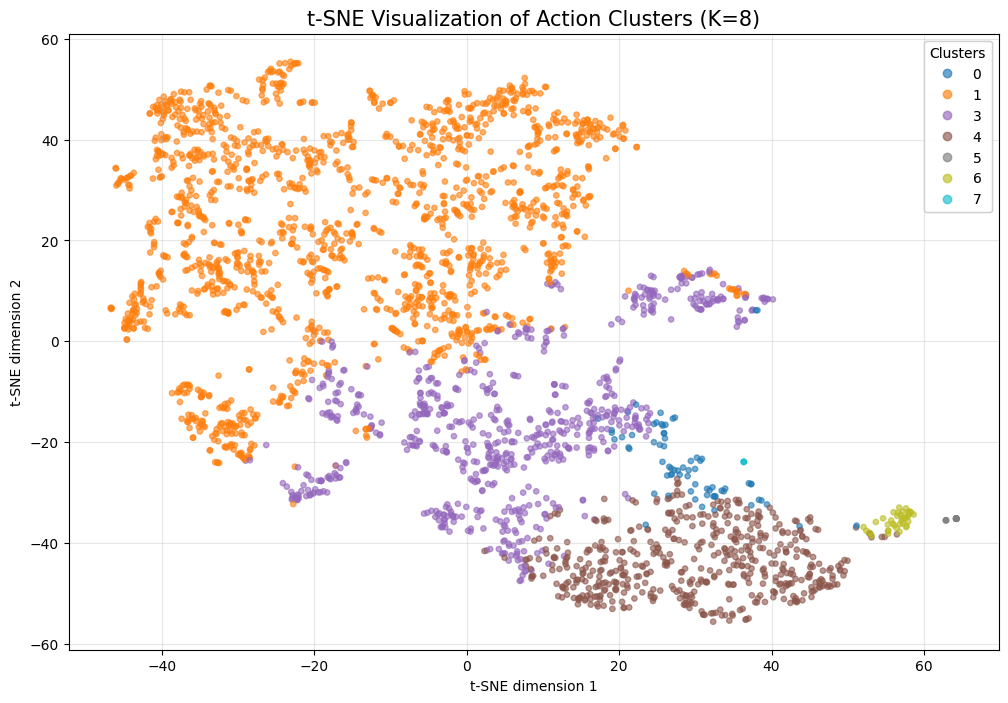

In [36]:
from sklearn.manifold import TSNE
import pandas as pd

sample_size = 3000 
indices = np.linspace(0, len(X_scaled_deg_speed_accel) - 1, sample_size).astype(int)
X_sample = X_scaled_deg_speed_accel[indices]
labels_sample = labels[indices]

tsne = TSNE(n_components=2, perplexity=30, random_state=42, init='pca', learning_rate='auto')
X_tsne = tsne.fit_transform(X_sample)


plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], 
                      c=labels_sample, 
                      cmap='tab10', 
                      alpha=0.6, 
                      s=15)


legend1 = plt.legend(*scatter.legend_elements(), title="Clusters")
plt.gca().add_artist(legend1)

plt.title(f"t-SNE Visualization of Action Clusters (K={optimal_k})", fontsize=15)
plt.xlabel("t-SNE dimension 1")
plt.ylabel("t-SNE dimension 2")
plt.grid(True, alpha=0.3)
plt.show()

In [37]:
pt_path = r"C:\Users\loy49\Desktop\REPO\LSTM_HRC\data\dataset"

In [38]:
def plot_hybrid_feature_heatmap(X_stacked, data_path, n_clusters=5, target_steps=100):
    # get all .pt files
    pt_files = sorted(glob.glob(os.path.join(data_path, "*.pt")))
    if not pt_files:
        print(".pt files not found in the specified directory.")
        return

    # 2. global K-Means clustering on the stacked features
    print("Performing K-Means clustering on combined features...")
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    global_labels = kmeans.fit_predict(X_stacked)

    # 3. construct parallel matrix for each video
    parallel_matrix = []
    video_names = []
    current_ptr = 0 #

    for pf in pt_files:
        data = torch.load(pf, weights_only=False)
        video_name = os.path.basename(pf).replace(".pt", "")
        
        # get number of frames for this video
        num_frames = data['landmarks'].shape[0]
        
        # extract corresponding cluster labels for this video's frames
        video_labels = global_labels[current_ptr : current_ptr + num_frames]
        current_ptr += num_frames
        
        # align (Resampling to 0-100%)
        if len(video_labels) > 0:
            indices = np.linspace(0, len(video_labels) - 1, target_steps).astype(int)
            resampled_labels = video_labels[indices]
            
            parallel_matrix.append(resampled_labels)
            video_names.append(video_name)

    # 4. plot heatmap
    parallel_matrix = np.array(parallel_matrix)
    plt.figure(figsize=(16, max(6, len(video_names) * 0.5)))
    
    cmap = plt.get_cmap("tab20", n_clusters)
    sns.heatmap(parallel_matrix, 
                cmap=cmap, 
                xticklabels=10, 
                yticklabels=video_names,
                cbar_kws={'label': 'Cluster ID', 'ticks': range(n_clusters)})

    plt.title(f"Hybrid Feature Pattern Analysis (K={n_clusters})", fontsize=15)
    plt.xlabel("Task Progress (%)", fontsize=12)
    plt.ylabel("Video Samples", fontsize=12)
    
    # 5% interval ticks
    plt.xticks(np.linspace(0, target_steps, 21), [f"{i*5}%" for i in range(21)])
    
    plt.tight_layout()
    plt.show()

    return kmeans, parallel_matrix

In [39]:
cluster = optimal_k

Performing K-Means clustering on combined features...


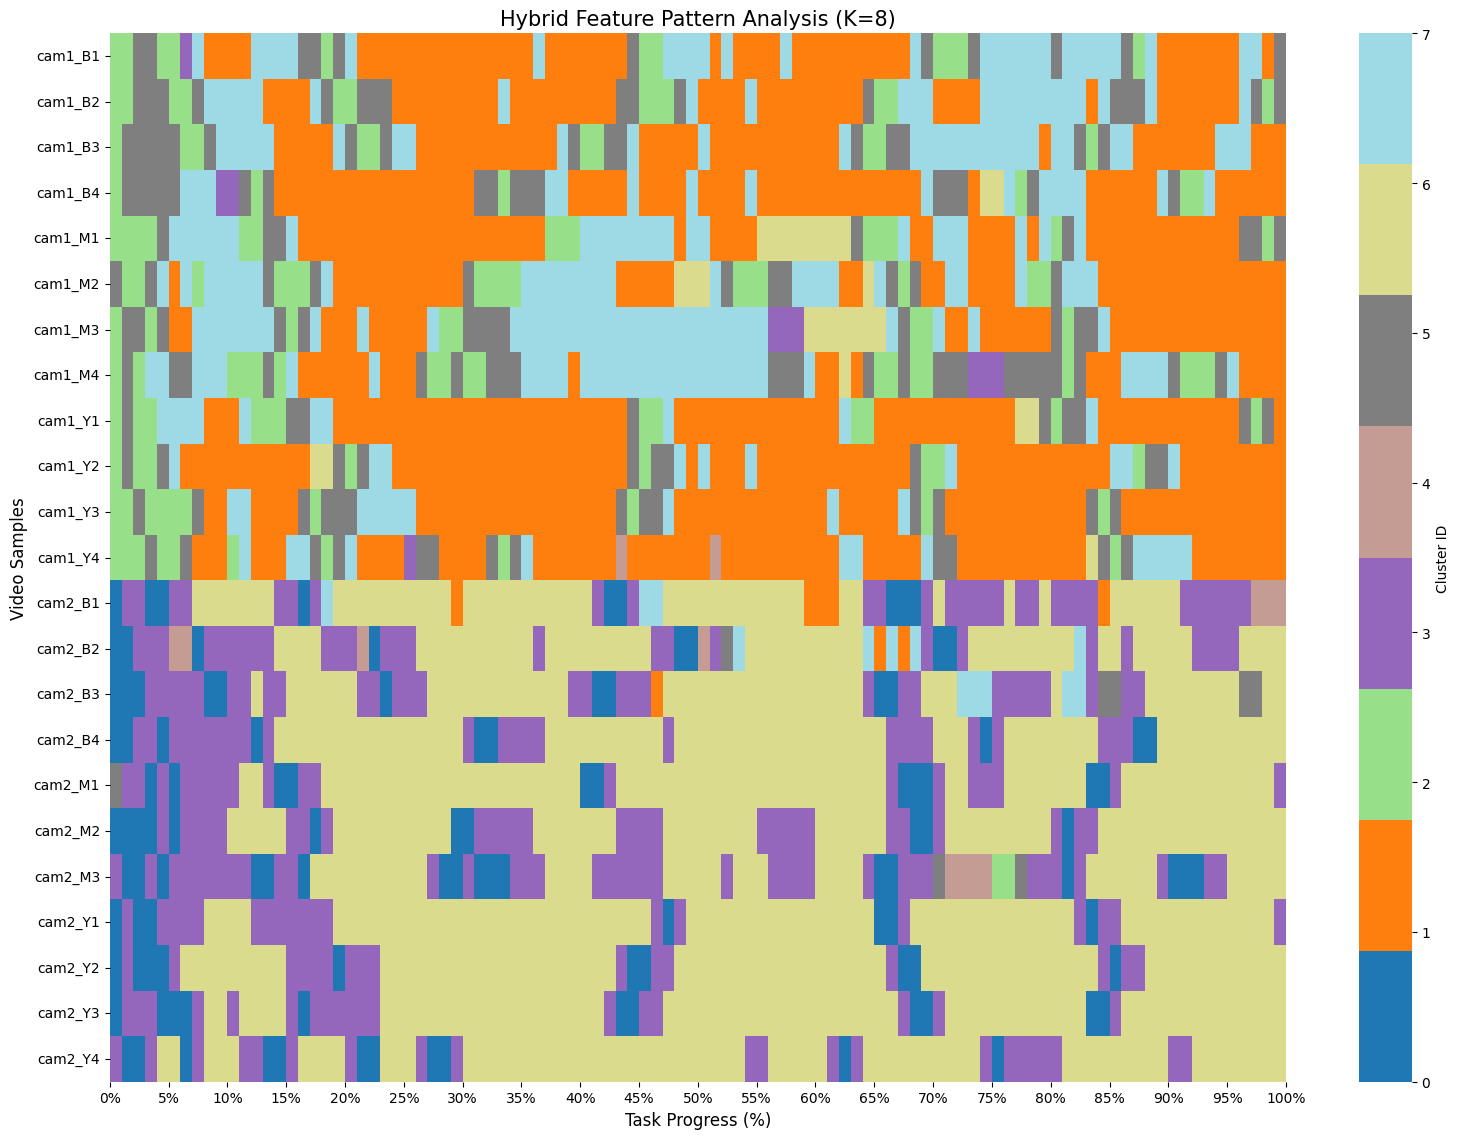

In [40]:
#posture + degree
kmeans_all, parallel_matrix_all = plot_hybrid_feature_heatmap(X_scaled_all, pt_path, n_clusters=cluster)

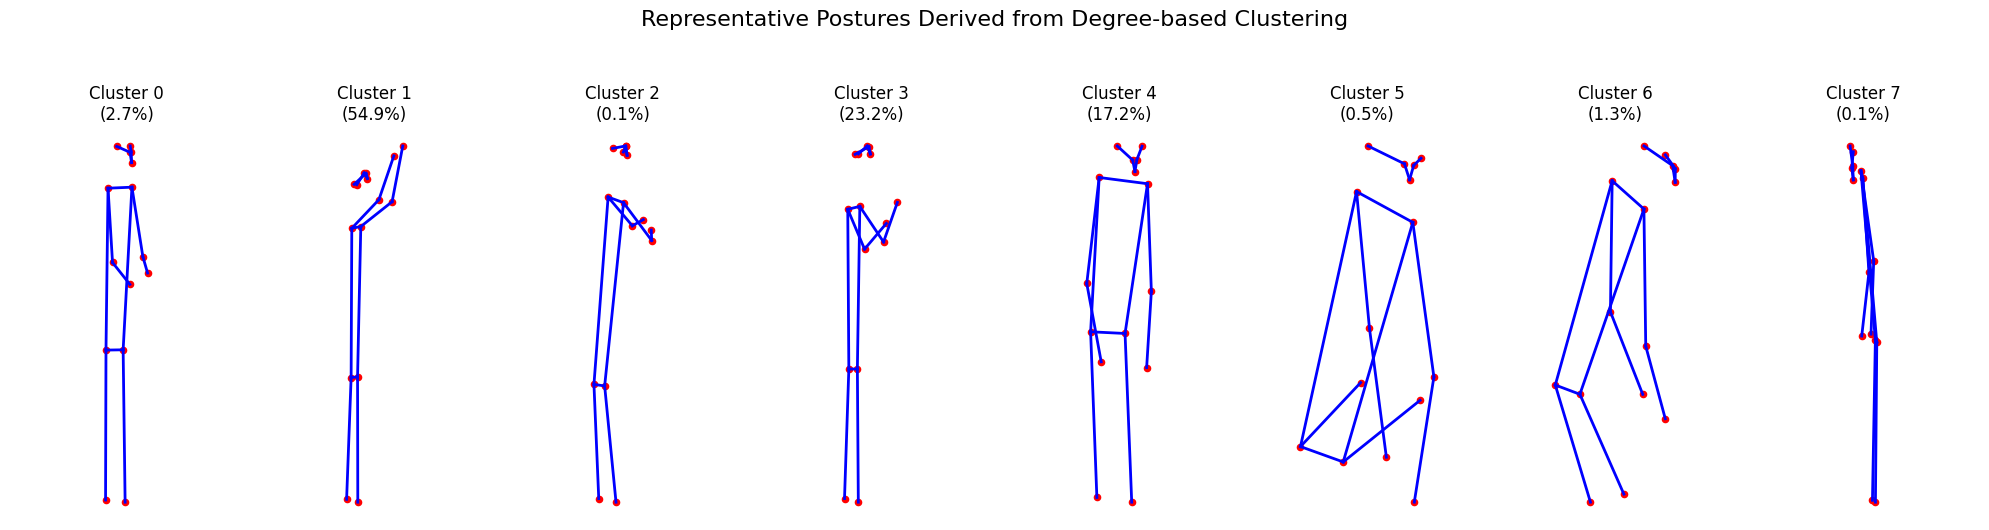

In [41]:
def plot_skeleton(points, title, ax):
    EDGES = [
        # Face
        (0, 1), (0, 2), (1, 3), (2, 4), 
        # Upper Body & Arms
        (5, 6), (5, 7), (7, 9), (6, 8), (8, 10),
        # Torso
        (5, 11), (6, 12), (11, 12),
        # Lower Body & Legs
        (11, 13), (12, 14)
        # (11, 13), (13, 15), (12, 14), (14, 16)
    ]
    pts = points.reshape(15, 2)
    ax.scatter(pts[:, 0], -pts[:, 1], c='red', s=20) 
    for edge in EDGES:
        ax.plot([pts[edge[0], 0], pts[edge[1], 0]], 
                 [-pts[edge[0], 1], -pts[edge[1], 1]], 'b-', linewidth=2)
    ax.set_title(title, fontsize=12)
    ax.axis('equal')
    ax.axis('off') 

# find representative postures for each cluster and plot them
plt.figure(figsize=(20, 5))

# X_scaled_deg.shape[1] = 9
# X_pos.shape[1] = 22 (skeleton points)
for i in range(optimal_k):
    cluster_indices = np.where(labels == i)[0]
    
    if len(cluster_indices) > 0:
        cluster_postures = X_pos[cluster_indices]

        representative_posture = np.mean(cluster_postures, axis=0)
        
        ax = plt.subplot(1, optimal_k, i+1)
        
        percentage = (len(cluster_indices) / len(labels)) * 100
        title_str = f"Cluster {i}\n({percentage:.1f}%)"
        
        plot_skeleton(representative_posture, title_str, ax)
    else:
        print(f"Warning: Cluster {i} has no samples.")

plt.suptitle("Representative Postures Derived from Degree-based Clustering", fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

Performing K-Means clustering on combined features...


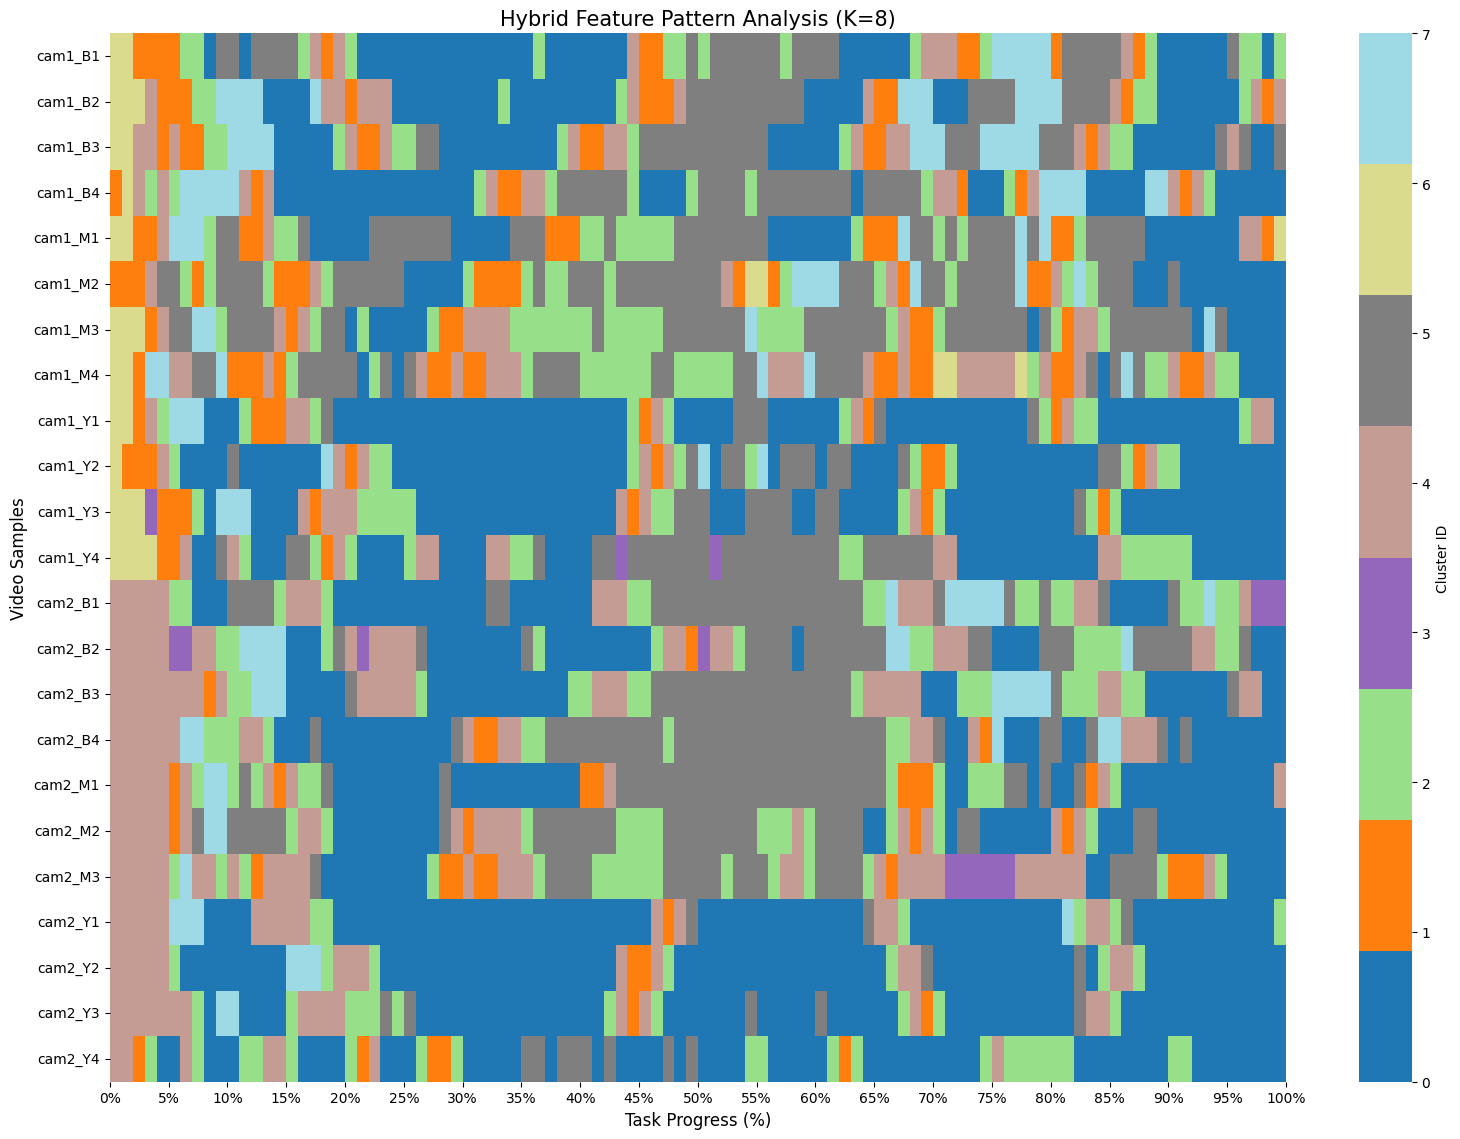

In [42]:
#degree only
kmeans_deg, parallel_matrix_deg = plot_hybrid_feature_heatmap(X_scaled_deg, pt_path, n_clusters=cluster)
# cluster 0: 4378 26.9%
# cluster 1: 156 1.0%
# cluster 2: 2572 15.8%
# cluster 3: 9057 55.7%
# cluster 4: 87 0.5%

Performing K-Means clustering on combined features...


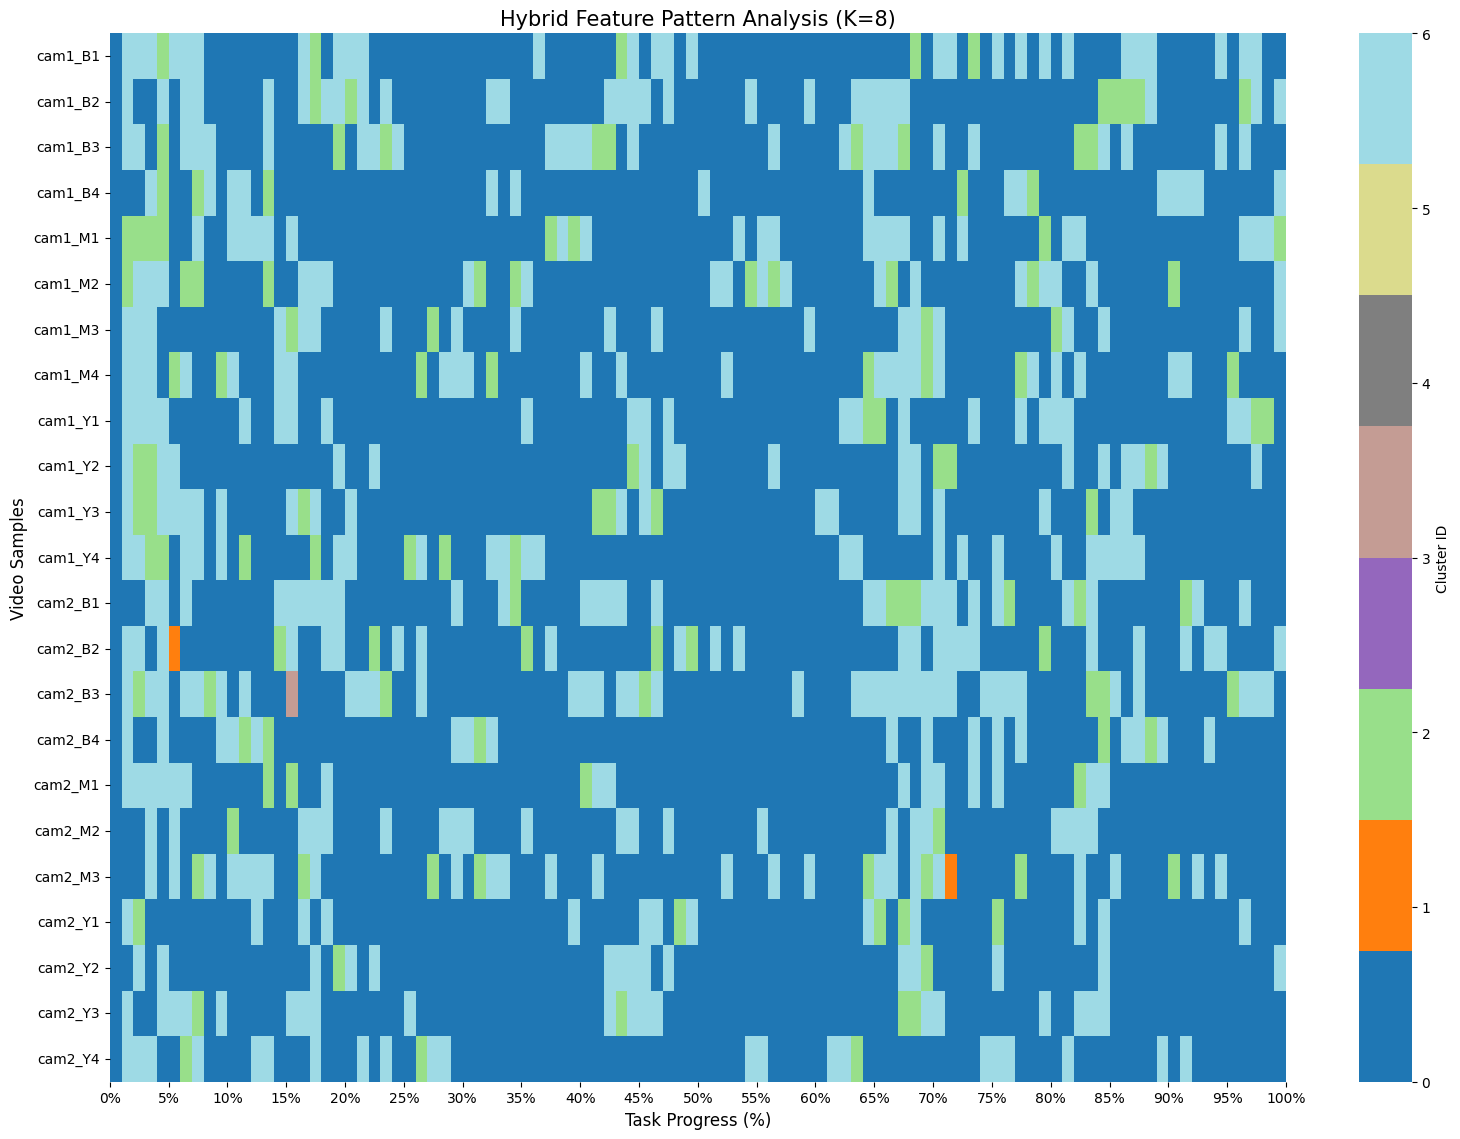

Performing K-Means clustering on combined features...


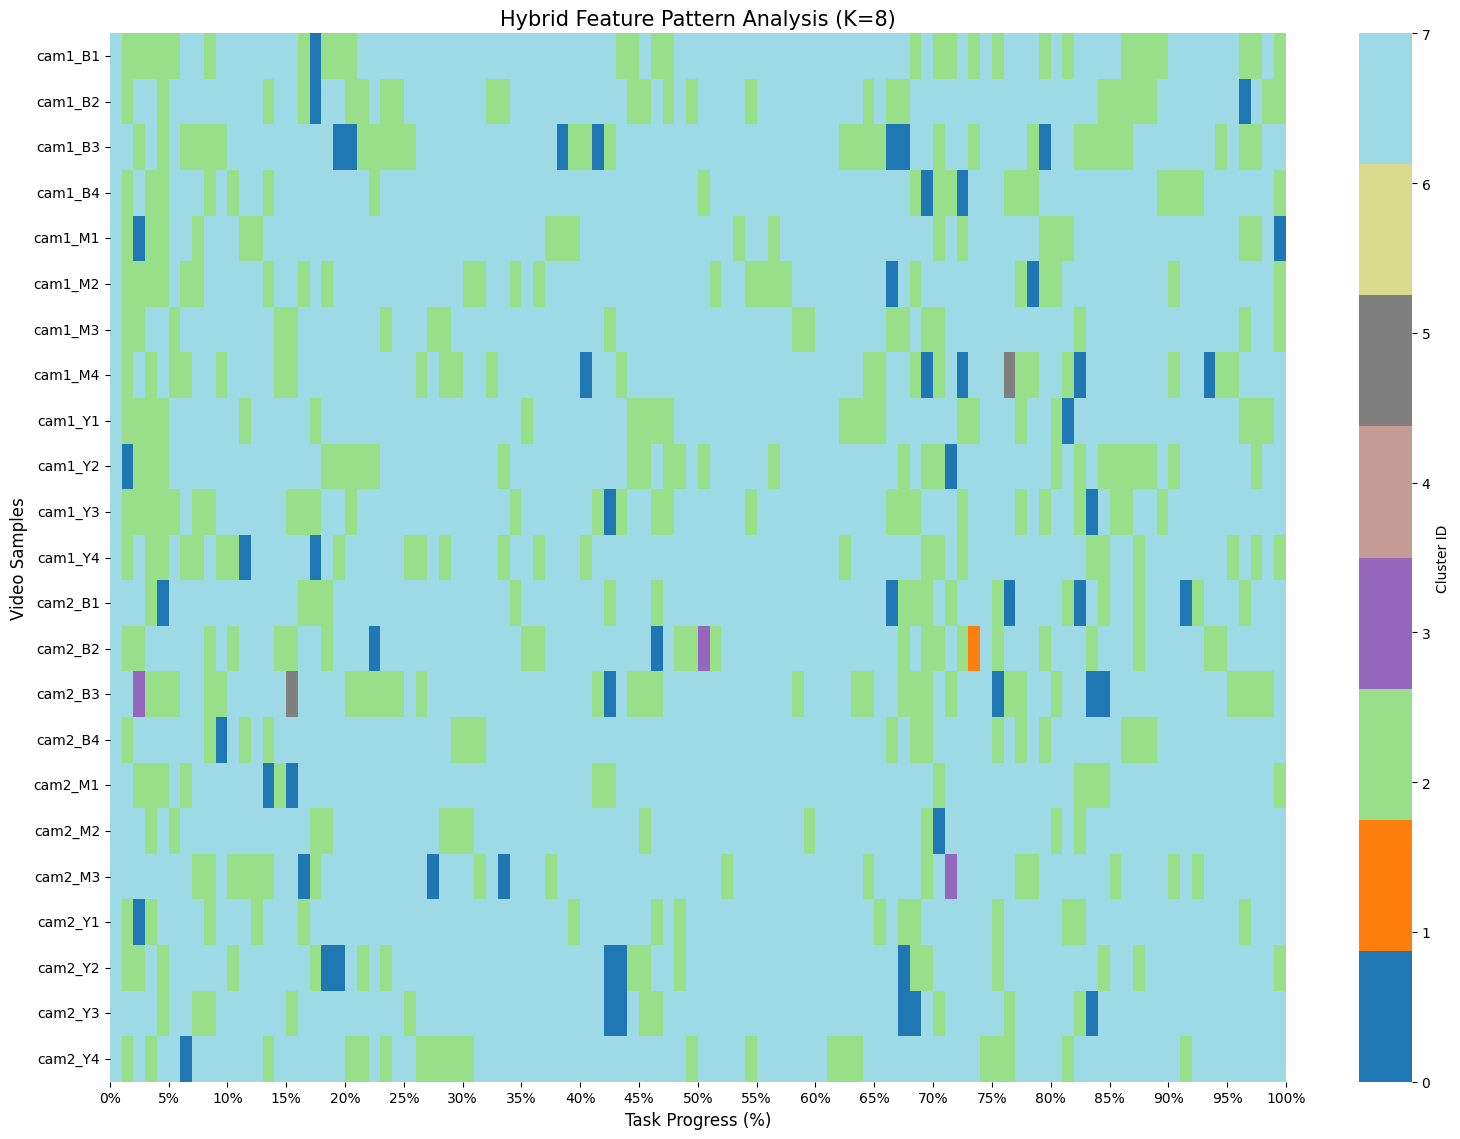

Performing K-Means clustering on combined features...


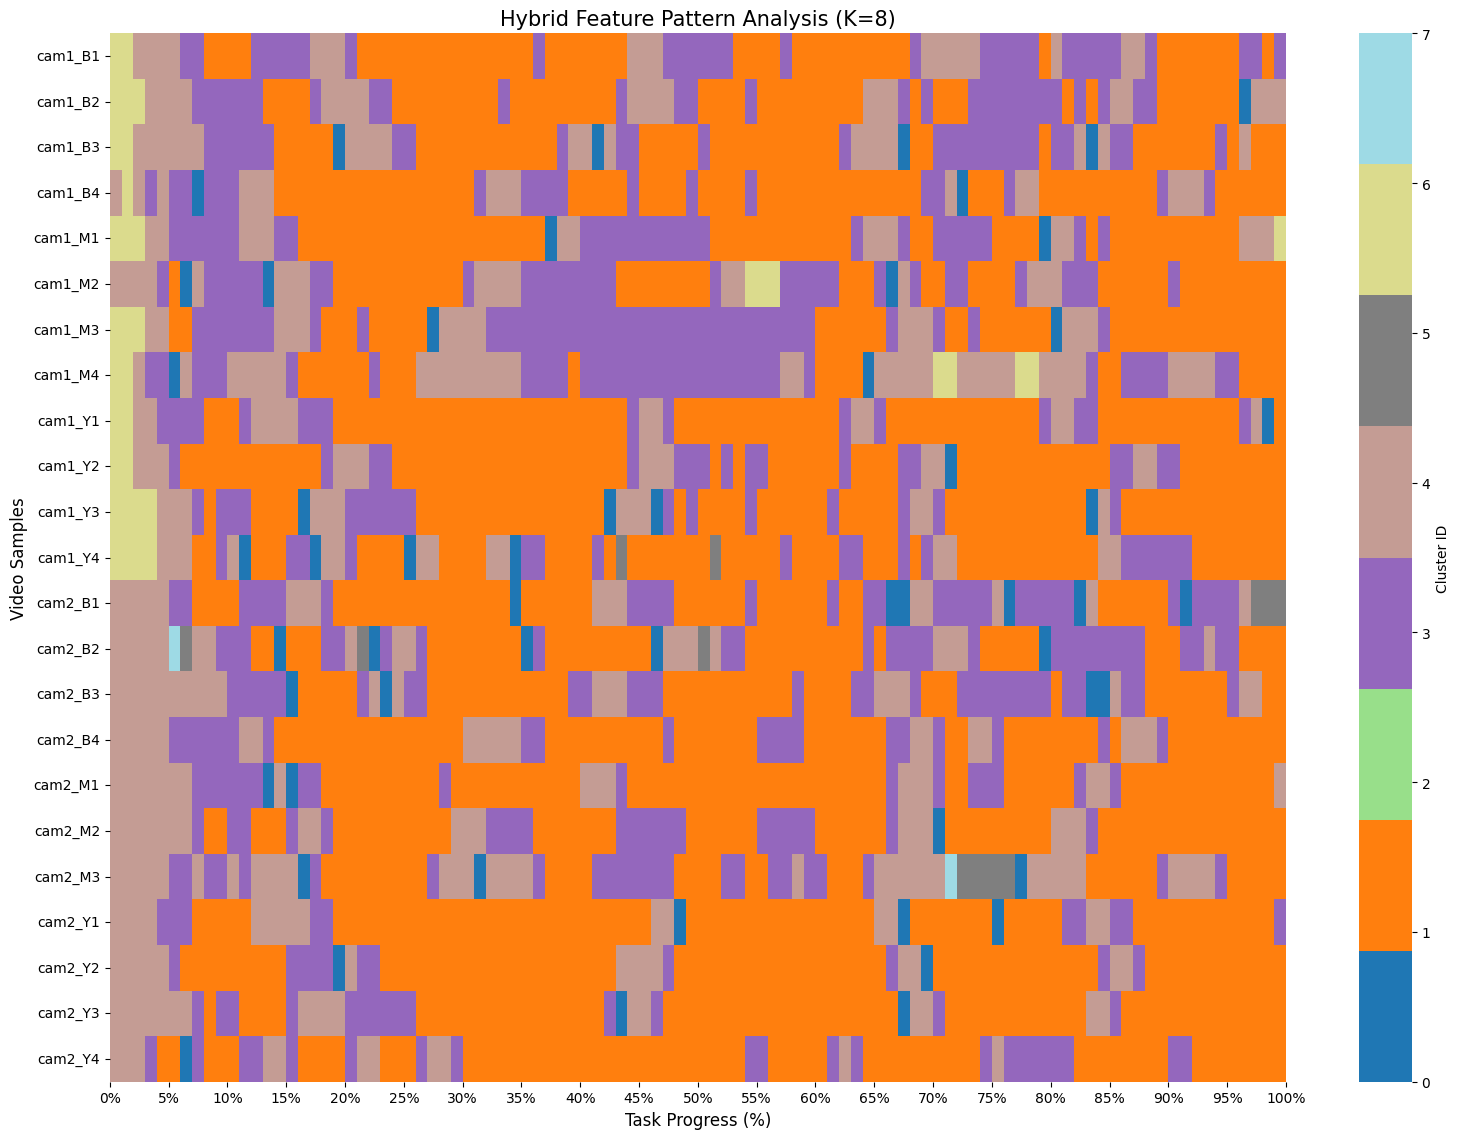

Performing K-Means clustering on combined features...


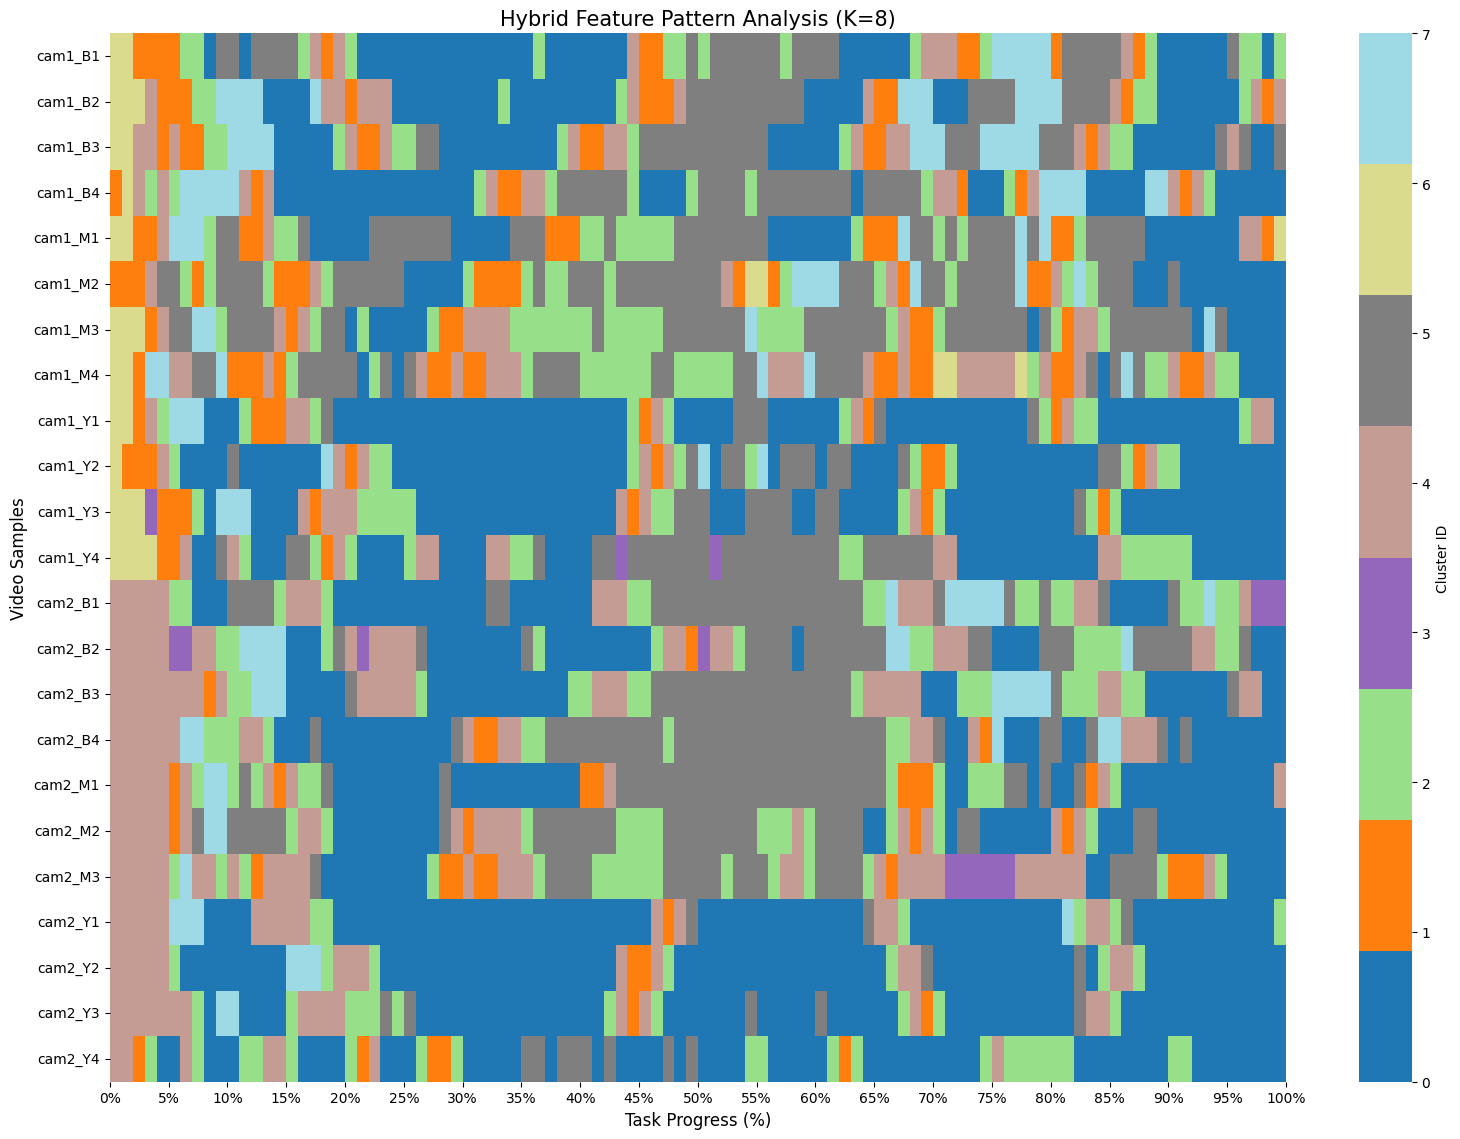

In [43]:

#speed only
kmeans_speed, parallel_matrix_speed = plot_hybrid_feature_heatmap(X_scaled_speed, pt_path, n_clusters=cluster)
#acc only
kmeans_accel, parallel_matrix_accel = plot_hybrid_feature_heatmap(X_scaled_accel, pt_path, n_clusters=cluster)
#degree + speed + accel
kmeans_deg_accel, parallel_matrix_deg_accel = plot_hybrid_feature_heatmap(X_scaled_deg_speed_accel, pt_path, n_clusters=cluster)
kmeans_deg, parallel_matrix_deg = plot_hybrid_feature_heatmap(X_scaled_deg, pt_path, n_clusters=cluster)

Performing K-Means clustering on combined features...


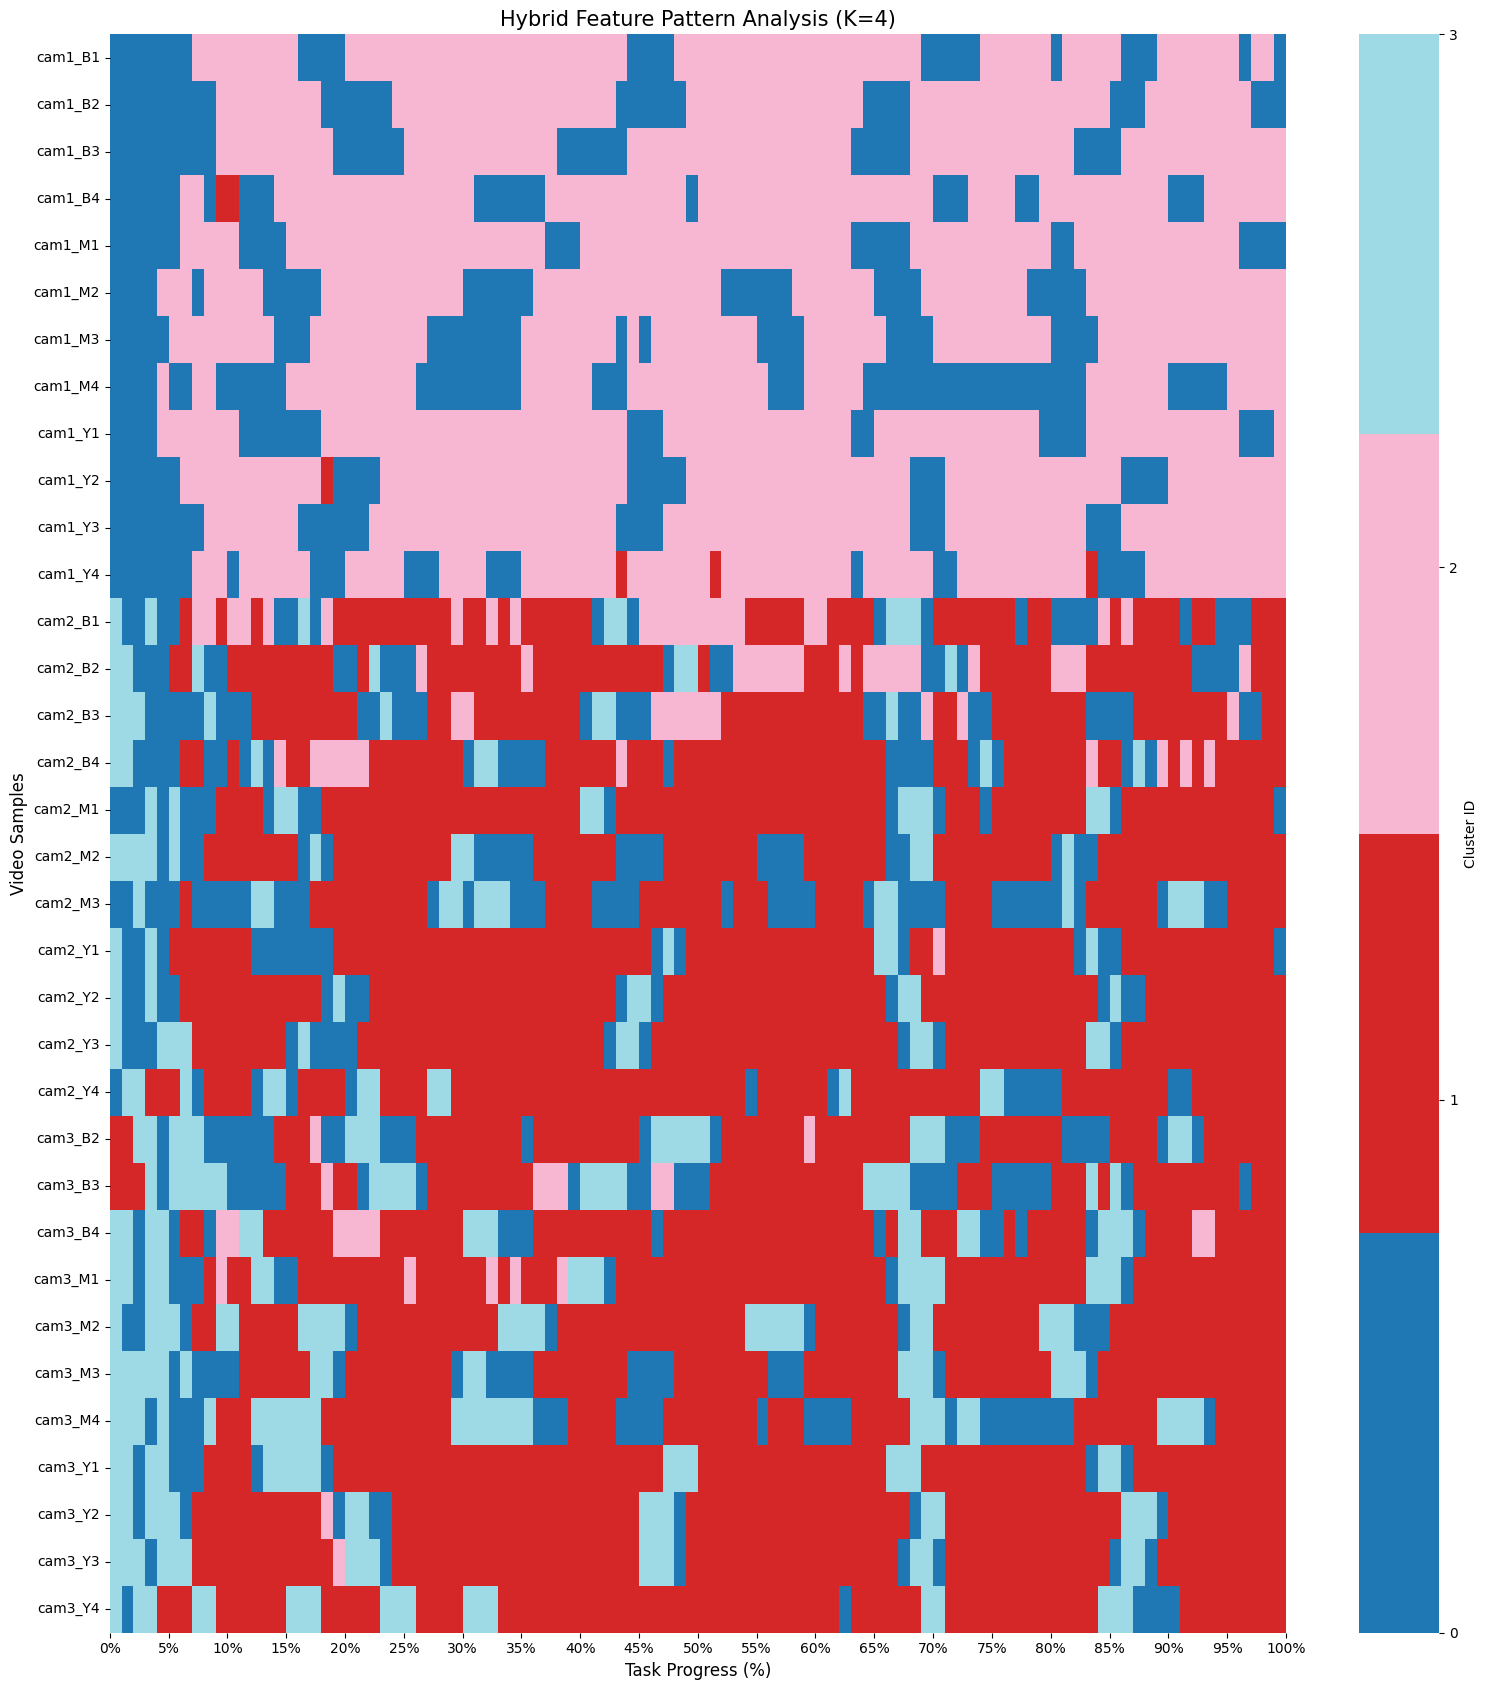

In [21]:
#posture only
kmeans_pos, parallel_matrix_pos = plot_hybrid_feature_heatmap(X_scaled_pos, pt_path, n_clusters=cluster)